<a href="https://colab.research.google.com/github/SHEisSONALI/Smart-City-AQI/blob/Sonali/notebook/Smart_City_AQI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install pandas

In [2]:
# Install the Kaggle API client
!pip install --upgrade kaggle

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.5/111.5 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 247.5/247.5 kB 13.6 MB/s eta 0:00:00
  Attempting uninstall: kagglesdk
    Found existing installation: kagglesdk 0.1.23
    Uninstalling kagglesdk-0.1.23:
      Successfully uninstalled kagglesdk-0.1.23
  Attempting uninstall: kaggle
    Found existing installation: kaggle 2.0.2
    Uninstalling kaggle-2.0.2:
      Successfully uninstalled kaggle-2.0.2


In [ ]:
!pip install python-dotenv

In [ ]:
from dotenv import load_dotenv
import os

load_dotenv()
kaggle_username = os.getenv("KAGGLE_USERNAME")
kaggle_key = os.getenv("KAGGLE_KEY")


In [3]:
import os
# os.environ['KAGGLE_API_TOKEN'] = "KGAT_7cdb4bd330a96fdf4b582337b2a3e90d" # Removed as kaggle.json is the preferred method for CLI

In [4]:
import json

token = {"username":"sonaliishekhawat","key":"KGAT_7cdb4bd330a96fdf4b582337b2a3e90d"}

with open("kaggle.json", "w") as f:
    json.dump(token, f)

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [5]:
!kaggle competitions list

Authentication required to call the Kaggle API.

First, you will need a Kaggle account. You can sign up at
  https://www.kaggle.com/account/login

Recommended: log in with OAuth via a web-based authorization flow.
No token to manage; credentials are cached locally for you.
    kaggle auth login

If you'd rather not use OAuth, generate an API token at
  https://www.kaggle.com/settings/api  (click "Generate New Token" under "API")
and supply it to the CLI in one of these ways:

  Option A: Environment variable
    export KAGGLE_API_TOKEN=xxxxxxxxxxxxxx  # token copied from the settings UI

  Option B: API token file
    Save the token to ~/.kaggle/access_token


After running the above cell, you should be able to re-run your `!kaggle datasets download` commands from cell `cf1def9d` without the `403 Forbidden` error.

### Downloading and Loading Datasets from Kaggle

To download datasets from Kaggle, use the `kaggle datasets download` command followed by the dataset identifier. The identifier usually follows the format `username/dataset-slug`.

In [6]:
!kaggle datasets download -d shrutibhargava94/india-air-quality-data

Dataset URL: https://www.kaggle.com/datasets/shrutibhargava94/india-air-quality-data
License(s): other
100% 5.22M/5.22M [00:00<00:00, 7.27MB/s]



After downloading, Kaggle datasets are often in a `.zip` format. You'll need to unzip them to access the CSV files.

In [7]:
# Unzip the downloaded dataset
!unzip -o india-air-quality-data.zip

Archive:  india-air-quality-data.zip
  inflating: data.csv                


Now, let's load these unzipped CSV files into pandas DataFrames and display their first few rows.

In [8]:
import pandas as pd

# Load the India Air Quality dataset, specifying 'latin1' encoding
air_quality_df = pd.read_csv('data.csv', encoding='latin1')
print('India Air Quality Dataset Head:')
display(air_quality_df.head())

/tmp/ipykernel_2489/3719561915.py:4: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  air_quality_df = pd.read_csv('data.csv', encoding='latin1')


India Air Quality Dataset Head:


,stn_code,sampling_date,state,location,agency,type,so2,no2,rspm,spm,location_monitoring_station,pm2_5,date
0,150.0,February - M021990,Andhra Pradesh,Hyderabad,NaN,"Residential, Rural and other Areas",4.8,17.4,NaN,NaN,NaN,NaN,1990-02-01
1,151.0,February - M021990,Andhra Pradesh,Hyderabad,NaN,Industrial Area,3.1,7.0,NaN,NaN,NaN,NaN,1990-02-01
2,152.0,February - M021990,Andhra Pradesh,Hyderabad,NaN,"Residential, Rural and other Areas",6.2,28.5,NaN,NaN,NaN,NaN,1990-02-01
3,150.0,March - M031990,Andhra Pradesh,Hyderabad,NaN,"Residential, Rural and other Areas",6.3,14.7,NaN,NaN,NaN,NaN,1990-03-01
4,151.0,March - M031990,Andhra Pradesh,Hyderabad,NaN,Industrial Area,4.7,7.5,NaN,NaN,NaN,NaN,1990-03-01


In [9]:
import pandas as pd

# Load the Smart Mobility dataset, trying 'latin1' encoding
smart_mobility_df = pd.read_csv('/content/Smart Mobility new.csv', encoding='latin1')
print('Smart Mobility Dataset Head:')
display(smart_mobility_df.head())

Smart Mobility Dataset Head:


,Traffic_Light_State,Weather_Condition,Traffic_Condition,Latitude,Longitude,Vehicle_Count,Traffic_Speed_kmh,Road_Occupancy_%,Accident_Report,Sentiment_Score,Ride_Sharing_Demand,Parking_Availability,Emission_Levels_g_km,Energy_Consumption_L_h
0,Yellow,Clear,High,40.842.275.292.891.800,-7.370.314.869.323.040,205,4.989.343.479.610.330,8.265.277.992.850.860,0,-6.091.990.900.689.380,2,45,4.507.600.550.695.170,"195743365296003000,00%"
1,Green,Clear,High,408.311.193.987.152,-739.873.540.904.415,202,22.383.964.870.087.800,4.582.929.780.270.140,0,965.442.369.948.869,16,1,3.218.003.405.168.860,"538555351219373000,00%"
2,Green,Rain,High,4.081.954.876.392.320,-7.373.246.185.831.270,252,46.889.699.439.334.800,8.277.246.480.269.830,0,2.896.603.158.283.980,16,49,2.311.526.548.042.290,"1027747748641990000,00%"
3,Red,Fog,High,4.072.584.887.921.560,-7.398.013.411.315.870,37,573.053.642.288.215,3.769.556.743.980.880,0,-27.196.473.819.133.900,66,10,4.103.842.921.098.870,"2924327944996020000,00%"
4,Green,Clear,High,4.064.111.174.659.450,-7.382.509.533.565.380,125,9.150.745.620.777.420,7.279.990.343.468.820,0,-5.946.363.258.437.670,78,27,3.490.453.075.341.280,"2980584193833020000,00%"


Now that both datasets are loaded, please examine the heads of both `air_quality_df` and `smart_mobility_df` to identify the common column(s) you'd like to use for merging. Once you tell me the column name(s), I can proceed with the merge operation.

In [10]:
print('--- Info for air_quality_df ---')
air_quality_df.info()

print('\n--- Info for smart_mobility_df ---')
smart_mobility_df.info()

--- Info for air_quality_df ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 435742 entries, 0 to 435741
Data columns (total 13 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   stn_code                     291665 non-null  object 
 1   sampling_date                435739 non-null  object 
 2   state                        435742 non-null  object 
 3   location                     435739 non-null  object 
 4   agency                       286261 non-null  object 
 5   type                         430349 non-null  object 
 6   so2                          401096 non-null  float64
 7   no2                          419509 non-null  float64
 8   rspm                         395520 non-null  float64
 9   spm                          198355 non-null  float64
 10  location_monitoring_station  408251 non-null  object 
 11  pm2_5                        9314 non-null    float64
 12  date                      

In [11]:
def clean_coordinate_string(coord_str):
    if pd.isna(coord_str): # Handle potential NaN values
        return np.nan

    s = str(coord_str) # Ensure it's a string
    parts = s.split('.', 1) # Split only at the first period
    if len(parts) > 1:
        # Keep the integer part, and remove all periods from the fractional part
        cleaned_fractional = parts[1].replace('.', '')
        return float(parts[0] + '.' + cleaned_fractional)
    else:
        # If no period, try direct conversion to float
        try:
            return float(s.replace('.', '')) # If it's an integer like string with periods, remove all
        except ValueError:
            return np.nan # If it can't be converted, return NaN

# Apply the cleaning function and convert to numeric
smart_mobility_df['Latitude'] = smart_mobility_df['Latitude'].apply(clean_coordinate_string)
smart_mobility_df['Longitude'] = smart_mobility_df['Longitude'].apply(clean_coordinate_string)

print('Smart Mobility Dataset Head after cleaning coordinates:')
display(smart_mobility_df.head())

print('\n--- Info for smart_mobility_df after cleaning coordinates ---')
smart_mobility_df.info()

Smart Mobility Dataset Head after cleaning coordinates:


,Traffic_Light_State,Weather_Condition,Traffic_Condition,Latitude,Longitude,Vehicle_Count,Traffic_Speed_kmh,Road_Occupancy_%,Accident_Report,Sentiment_Score,Ride_Sharing_Demand,Parking_Availability,Emission_Levels_g_km,Energy_Consumption_L_h
0,Yellow,Clear,High,40.842275,-7.370315,205,4.989.343.479.610.330,8.265.277.992.850.860,0,-6.091.990.900.689.380,2,45,4.507.600.550.695.170,"195743365296003000,00%"
1,Green,Clear,High,408.311194,-739.873541,202,22.383.964.870.087.800,4.582.929.780.270.140,0,965.442.369.948.869,16,1,3.218.003.405.168.860,"538555351219373000,00%"
2,Green,Rain,High,4.081955,-7.373246,252,46.889.699.439.334.800,8.277.246.480.269.830,0,2.896.603.158.283.980,16,49,2.311.526.548.042.290,"1027747748641990000,00%"
3,Red,Fog,High,4.072585,-7.398013,37,573.053.642.288.215,3.769.556.743.980.880,0,-27.196.473.819.133.900,66,10,4.103.842.921.098.870,"2924327944996020000,00%"
4,Green,Clear,High,4.064111,-7.382510,125,9.150.745.620.777.420,7.279.990.343.468.820,0,-5.946.363.258.437.670,78,27,3.490.453.075.341.280,"2980584193833020000,00%"



--- Info for smart_mobility_df after cleaning coordinates ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Traffic_Light_State     5000 non-null   object 
 1   Weather_Condition       5000 non-null   object 
 2   Traffic_Condition       5000 non-null   object 
 3   Latitude                5000 non-null   float64
 4   Longitude               5000 non-null   float64
 5   Vehicle_Count           5000 non-null   int64  
 6   Traffic_Speed_kmh       5000 non-null   object 
 7   Road_Occupancy_%        5000 non-null   object 
 8   Accident_Report         5000 non-null   int64  
 9   Sentiment_Score         5000 non-null   object 
 10  Ride_Sharing_Demand     5000 non-null   int64  
 11  Parking_Availability    5000 non-null   int64  
 12  Emission_Levels_g_km    5000 non-null   object 
 13  Energy_Consumption_L_h  5000 n

In [12]:
import pandas as pd

# Corrected dataframe names, but a direct merge on 'location' is not possible
# because 'smart_mobility_df' does not have a 'location' column.
# We need to perform a spatial merge as outlined below.
# merged_df = pd.merge(air_quality_df, smart_mobility_df, on='location', how='inner')


In [13]:
# Install geopy for geocoding
!pip install geopy

In [14]:
from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter

# Initialize Nominatim geocoder with a user agent
geolocator = Nominatim(user_agent="colab_spatial_merge_app")

# Geocoding can take time and hit rate limits, so we'll use a rate limiter
geocode = RateLimiter(geolocator.geocode, min_delay_seconds=1, error_wait_seconds=5)


In [15]:
# Create a combined address string for geocoding
air_quality_df['address'] = air_quality_df['location'] + ', ' + air_quality_df['state'] + ', India'

# Get unique locations to avoid redundant geocoding calls
unique_locations = air_quality_df[['location', 'state', 'address']].drop_duplicates().copy()

# Apply geocoding to unique locations
# This can take a while depending on the number of unique locations
unique_locations['geocoded_location'] = unique_locations['address'].apply(geocode)

# Extract latitude and longitude
unique_locations['latitude_air'] = unique_locations['geocoded_location'].apply(lambda loc: loc.latitude if loc else None)
unique_locations['longitude_air'] = unique_locations['geocoded_location'].apply(lambda loc: loc.longitude if loc else None)

# Drop the intermediate 'geocoded_location' and 'address' columns from unique_locations if not needed
unique_locations = unique_locations.drop(columns=['geocoded_location', 'address'])

# Merge the geocoded coordinates back to the original air_quality_df
# We'll merge on 'location' and 'state' to match the coordinates
air_quality_df = pd.merge(air_quality_df, unique_locations, on=['location', 'state'], how='left')

print('Air Quality Dataset Head after geocoding:')
display(air_quality_df.head())

print('\n--- Info for air_quality_df after geocoding ---')
air_quality_df.info()

Air Quality Dataset Head after geocoding:


,stn_code,sampling_date,state,location,agency,type,so2,no2,rspm,spm,location_monitoring_station,pm2_5,date,address,latitude_air,longitude_air
0,150.0,February - M021990,Andhra Pradesh,Hyderabad,NaN,"Residential, Rural and other Areas",4.8,17.4,NaN,NaN,NaN,NaN,1990-02-01,"Hyderabad, Andhra Pradesh, India",15.814229,78.026808
1,151.0,February - M021990,Andhra Pradesh,Hyderabad,NaN,Industrial Area,3.1,7.0,NaN,NaN,NaN,NaN,1990-02-01,"Hyderabad, Andhra Pradesh, India",15.814229,78.026808
2,152.0,February - M021990,Andhra Pradesh,Hyderabad,NaN,"Residential, Rural and other Areas",6.2,28.5,NaN,NaN,NaN,NaN,1990-02-01,"Hyderabad, Andhra Pradesh, India",15.814229,78.026808
3,150.0,March - M031990,Andhra Pradesh,Hyderabad,NaN,"Residential, Rural and other Areas",6.3,14.7,NaN,NaN,NaN,NaN,1990-03-01,"Hyderabad, Andhra Pradesh, India",15.814229,78.026808
4,151.0,March - M031990,Andhra Pradesh,Hyderabad,NaN,Industrial Area,4.7,7.5,NaN,NaN,NaN,NaN,1990-03-01,"Hyderabad, Andhra Pradesh, India",15.814229,78.026808



--- Info for air_quality_df after geocoding ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 435742 entries, 0 to 435741
Data columns (total 16 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   stn_code                     291665 non-null  object 
 1   sampling_date                435739 non-null  object 
 2   state                        435742 non-null  object 
 3   location                     435739 non-null  object 
 4   agency                       286261 non-null  object 
 5   type                         430349 non-null  object 
 6   so2                          401096 non-null  float64
 7   no2                          419509 non-null  float64
 8   rspm                         395520 non-null  float64
 9   spm                          198355 non-null  float64
 10  location_monitoring_station  408251 non-null  object 
 11  pm2_5                        9314 non-null    float64
 12  date     

In [16]:
# Install scipy for spatial operations if not already installed
!pip install scipy

In [17]:
from scipy.spatial import cKDTree
import numpy as np

# Drop rows from air_quality_df where geocoding failed (latitude_air or longitude_air are NaN)
air_quality_df_cleaned = air_quality_df.dropna(subset=['latitude_air', 'longitude_air']).copy()

# Extract coordinates for air_quality_df
points_air_quality = air_quality_df_cleaned[['latitude_air', 'longitude_air']].values

# Extract coordinates for smart_mobility_df
# Ensure Latitude and Longitude are numeric (float) before using them
smart_mobility_df['Latitude'] = pd.to_numeric(smart_mobility_df['Latitude'], errors='coerce')
smart_mobility_df['Longitude'] = pd.to_numeric(smart_mobility_df['Longitude'], errors='coerce')

# Drop rows from smart_mobility_df where coordinates are NaN after cleaning
smart_mobility_df_cleaned = smart_mobility_df.dropna(subset=['Latitude', 'Longitude']).copy()

# Create a column in smart_mobility_df_cleaned that holds its original index values.
# This column will be used as the merge key on the right side after prefixing.
smart_mobility_df_cleaned['original_smart_mobility_index_col'] = smart_mobility_df_cleaned.index

points_smart_mobility = smart_mobility_df_cleaned[['Latitude', 'Longitude']].values

# Build a KD-Tree for efficient nearest neighbor search on smart_mobility_df points
tree = cKDTree(points_smart_mobility)

# Query the KD-Tree to find the nearest smart mobility point for each air quality point
# k=1 means we are looking for the single nearest neighbor
distances, indices = tree.query(points_air_quality, k=1)

# Add the distance and the ORIGINAL index label of the nearest smart mobility point to air_quality_df_cleaned
# 'smart_mobility_df_cleaned.index[indices]' correctly gets the actual index labels
air_quality_df_cleaned['nearest_smart_mobility_original_idx_label'] = smart_mobility_df_cleaned.index[indices]
air_quality_df_cleaned['nearest_smart_mobility_dist'] = distances

# Prepare smart_mobility_df_cleaned for merge: add prefix
# The 'original_smart_mobility_index_col' will become 'smart_mobility_original_smart_mobility_index_col'
smart_mobility_prefixed_for_merge = smart_mobility_df_cleaned.add_prefix('smart_mobility_')

# Merge air_quality_df_cleaned with the relevant columns from smart_mobility_df_cleaned
merged_spatial_df = pd.merge(
    air_quality_df_cleaned,
    smart_mobility_prefixed_for_merge,
    left_on='nearest_smart_mobility_original_idx_label', # Use the column holding original index labels
    right_on='smart_mobility_original_smart_mobility_index_col', # This is the prefixed version of the column created above
    how='left'
)

# Drop the temporary index column used for merging from the left DataFrame if desired
merged_spatial_df = merged_spatial_df.drop(columns=['nearest_smart_mobility_original_idx_label'], errors='ignore')

print('Merged DataFrame Head (spatial join):')
display(merged_spatial_df.head())

print('\n--- Info for merged_spatial_df ---')
merged_spatial_df.info()

Merged DataFrame Head (spatial join):


,stn_code,sampling_date,state,location,agency,type,so2,no2,rspm,spm,...,smart_mobility_Vehicle_Count,smart_mobility_Traffic_Speed_kmh,smart_mobility_Road_Occupancy_%,smart_mobility_Accident_Report,smart_mobility_Sentiment_Score,smart_mobility_Ride_Sharing_Demand,smart_mobility_Parking_Availability,smart_mobility_Emission_Levels_g_km,smart_mobility_Energy_Consumption_L_h,smart_mobility_original_smart_mobility_index_col
0,150.0,February - M021990,Andhra Pradesh,Hyderabad,NaN,"Residential, Rural and other Areas",4.8,17.4,NaN,NaN,...,102,15.275.013.949.175.300,6.965.197.114.607.490,0,524.105.493.456.382,74,32,47.731.651.354.026.500,"2800275759176600000,00%",2093
1,151.0,February - M021990,Andhra Pradesh,Hyderabad,NaN,Industrial Area,3.1,7.0,NaN,NaN,...,102,15.275.013.949.175.300,6.965.197.114.607.490,0,524.105.493.456.382,74,32,47.731.651.354.026.500,"2800275759176600000,00%",2093
2,152.0,February - M021990,Andhra Pradesh,Hyderabad,NaN,"Residential, Rural and other Areas",6.2,28.5,NaN,NaN,...,102,15.275.013.949.175.300,6.965.197.114.607.490,0,524.105.493.456.382,74,32,47.731.651.354.026.500,"2800275759176600000,00%",2093
3,150.0,March - M031990,Andhra Pradesh,Hyderabad,NaN,"Residential, Rural and other Areas",6.3,14.7,NaN,NaN,...,102,15.275.013.949.175.300,6.965.197.114.607.490,0,524.105.493.456.382,74,32,47.731.651.354.026.500,"2800275759176600000,00%",2093
4,151.0,March - M031990,Andhra Pradesh,Hyderabad,NaN,Industrial Area,4.7,7.5,NaN,NaN,...,102,15.275.013.949.175.300,6.965.197.114.607.490,0,524.105.493.456.382,74,32,47.731.651.354.026.500,"2800275759176600000,00%",2093



--- Info for merged_spatial_df ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 427872 entries, 0 to 427871
Data columns (total 32 columns):
 #   Column                                            Non-Null Count   Dtype  
---  ------                                            --------------   -----  
 0   stn_code                                          285349 non-null  object 
 1   sampling_date                                     427869 non-null  object 
 2   state                                             427872 non-null  object 
 3   location                                          427869 non-null  object 
 4   agency                                            280162 non-null  object 
 5   type                                              423388 non-null  object 
 6   so2                                               393339 non-null  float64
 7   no2                                               411779 non-null  float64
 8   rspm                                            

In [18]:
def clean_numeric_string(num_str):
    if pd.isna(num_str):
        return np.nan
    s = str(num_str).replace(' ', '') # Ensure string and remove any spaces
    # Handle percentage string like '2800275759176600000,00%'
    if ',' in s and '%' in s:
        s = s.replace(',', '.').replace('%', '') # Replace comma with period for decimal, remove percent sign
    elif ',' in s:
        # If only comma, assume it's a decimal separator for European format
        s = s.replace(',', '.')

    # Now handle multiple periods by keeping first one and removing others
    parts = s.split('.', 1)
    if len(parts) > 1:
        cleaned_fractional = parts[1].replace('.', '')
        return float(parts[0] + '.' + cleaned_fractional)
    else:
        try:
            return float(s.replace('.', '')) # If no period or single part, remove all periods (e.g., '123.456' -> 123456 or '123' -> 123)
        except ValueError:
            return np.nan

# Apply the cleaning function to relevant smart mobility columns
columns_to_clean = [
    'smart_mobility_Traffic_Speed_kmh',
    'smart_mobility_Road_Occupancy_%',
    'smart_mobility_Emission_Levels_g_km',
    'smart_mobility_Sentiment_Score',
    'smart_mobility_Energy_Consumption_L_h'
]

for col in columns_to_clean:
    if col in merged_spatial_df.columns:
        print(f"Cleaning and converting column: {col}")
        merged_spatial_df[col] = merged_spatial_df[col].apply(clean_numeric_string)
    else:
        print(f"Column {col} not found in merged_spatial_df.")

print('\n--- Info for merged_spatial_df after cleaning numeric columns ---')
merged_spatial_df.info()
display(merged_spatial_df[columns_to_clean].head())

Cleaning and converting column: smart_mobility_Traffic_Speed_kmh
Cleaning and converting column: smart_mobility_Road_Occupancy_%
Cleaning and converting column: smart_mobility_Emission_Levels_g_km
Cleaning and converting column: smart_mobility_Sentiment_Score
Cleaning and converting column: smart_mobility_Energy_Consumption_L_h

--- Info for merged_spatial_df after cleaning numeric columns ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 427872 entries, 0 to 427871
Data columns (total 32 columns):
 #   Column                                            Non-Null Count   Dtype  
---  ------                                            --------------   -----  
 0   stn_code                                          285349 non-null  object 
 1   sampling_date                                     427869 non-null  object 
 2   state                                             427872 non-null  object 
 3   location                                          427869 non-null  object 
 4   agency 

,smart_mobility_Traffic_Speed_kmh,smart_mobility_Road_Occupancy_%,smart_mobility_Emission_Levels_g_km,smart_mobility_Sentiment_Score,smart_mobility_Energy_Consumption_L_h
0,15.275014,6.965197,47.731651,524.105493,2.800276e+18
1,15.275014,6.965197,47.731651,524.105493,2.800276e+18
2,15.275014,6.965197,47.731651,524.105493,2.800276e+18
3,15.275014,6.965197,47.731651,524.105493,2.800276e+18
4,15.275014,6.965197,47.731651,524.105493,2.800276e+18


In [19]:
# Define air quality metrics and traffic speed for correlation analysis
air_quality_metrics = ['so2', 'no2', 'pm2_5', 'rspm', 'spm']
traffic_speed_col = 'smart_mobility_Emission_Levels_g_km'

# Calculate correlations
correlations = {}
for aq_metric in air_quality_metrics:
    if aq_metric in merged_spatial_df.columns and traffic_speed_col in merged_spatial_df.columns:
        # Drop NaN values for accurate correlation calculation
        temp_df = merged_spatial_df[[aq_metric, traffic_speed_col]].dropna()
        if not temp_df.empty:
            correlation = temp_df[aq_metric].corr(temp_df[traffic_speed_col])
            correlations[f'{aq_metric}_vs_emission'] = correlation
        else:
            correlations[f'{aq_metric}_vs_emission'] = np.nan # No data for correlation
    else:
        correlations[f'{aq_metric}_vs_emission'] = np.nan # Column not found

# Display correlations
print("\nCorrelation between Air Quality Metrics and Traffic Speed:")
for metric, corr_val in correlations.items():
    print(f"- {metric}: {corr_val:.4f}")


Correlation between Air Quality Metrics and Traffic Speed:
- so2_vs_emission: 0.0722
- no2_vs_emission: -0.1026
- pm2_5_vs_emission: -0.3567
- rspm_vs_emission: -0.3282
- spm_vs_emission: -0.3402


### Predicting Air Quality Index (AQI) using Linear Regression

To predict AQI, we first need to define an AQI metric from the available air quality pollutants. Since there isn't a universally standard simple formula for AQI given these specific metrics, and `pm2_5` has very few non-null values, we will create a simplified `Air_Quality_Index` by taking the average of `so2`, `no2`, `rspm`, and `spm` for each location, ignoring `NaN` values in the average calculation. This approach allows us to utilize the most abundant air quality data.

In [20]:
import numpy as np

# Define the air quality columns to be used for a simplified AQI calculation
aqi_columns = ['so2', 'no2', 'rspm', 'spm']

# Calculate a simplified Air Quality Index (AQI) by averaging the available pollutants
# We use `axis=1` to calculate the mean across columns for each row, and `skipna=True`
# to ignore NaN values in the average calculation.
merged_spatial_df['Air_Quality_Index'] = merged_spatial_df[aqi_columns].mean(axis=1, skipna=True)

print('Merged DataFrame Head with new Air_Quality_Index:')
display(merged_spatial_df[['Air_Quality_Index'] + aqi_columns].head())

print('\n--- Info for merged_spatial_df after AQI calculation ---')
merged_spatial_df.info()

Merged DataFrame Head with new Air_Quality_Index:


,Air_Quality_Index,so2,no2,rspm,spm
0,11.10,4.8,17.4,NaN,NaN
1,5.05,3.1,7.0,NaN,NaN
2,17.35,6.2,28.5,NaN,NaN
3,10.50,6.3,14.7,NaN,NaN
4,6.10,4.7,7.5,NaN,NaN



--- Info for merged_spatial_df after AQI calculation ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 427872 entries, 0 to 427871
Data columns (total 33 columns):
 #   Column                                            Non-Null Count   Dtype  
---  ------                                            --------------   -----  
 0   stn_code                                          285349 non-null  object 
 1   sampling_date                                     427869 non-null  object 
 2   state                                             427872 non-null  object 
 3   location                                          427869 non-null  object 
 4   agency                                            280162 non-null  object 
 5   type                                              423388 non-null  object 
 6   so2                                               393339 non-null  float64
 7   no2                                               411779 non-null  float64
 8   rspm                      

Now, let's prepare the data for linear regression. We'll use `Air_Quality_Index` as our target variable and `smart_mobility_Traffic_Speed_kmh` as our primary feature. We'll also include other cleaned numeric `smart_mobility_` columns as potential features to build a more comprehensive model.

In [25]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import joblib

# --- Step 1: Feature Engineering ---
merged_spatial_df['date'] = pd.to_datetime(merged_spatial_df['date'])
merged_spatial_df = merged_spatial_df.sort_values(by=['location', 'date'])

# Rolling averages per location
merged_spatial_df['AQI_roll7'] = merged_spatial_df.groupby('location')['Air_Quality_Index'].transform(
    lambda x: x.rolling(window=7, min_periods=1).mean())
merged_spatial_df['AQI_roll30'] = merged_spatial_df.groupby('location')['Air_Quality_Index'].transform(
    lambda x: x.rolling(window=30, min_periods=1).mean())

# Lag features
merged_spatial_df['AQI_lag1'] = merged_spatial_df.groupby('location')['Air_Quality_Index'].shift(1)
merged_spatial_df['AQI_lag3'] = merged_spatial_df.groupby('location')['Air_Quality_Index'].shift(3)
merged_spatial_df['AQI_lag7'] = merged_spatial_df.groupby('location')['Air_Quality_Index'].shift(7)

# Seasonality
merged_spatial_df['month'] = merged_spatial_df['date'].dt.month
merged_spatial_df['dayofweek'] = merged_spatial_df['date'].dt.dayofweek

# --- Step 2: Define target and features ---
target = 'Air_Quality_Index'
features = [
    'smart_mobility_Road_Occupancy_%',
    'smart_mobility_Emission_Levels_g_km',
    'smart_mobility_Sentiment_Score',
    'smart_mobility_Energy_Consumption_L_h',
    'AQI_roll7',
    'AQI_roll30',
    'AQI_lag1',
    'AQI_lag3',
    'AQI_lag7',
    'month',
    'dayofweek'
]

regression_df = merged_spatial_df[[target] + features].dropna()
X = regression_df[features]
y = regression_df[target]

print(f"Dataset size after feature engineering: {regression_df.shape[0]} rows")

# --- Step 3: Train/Test Split ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- Step 4: Scaling ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- Step 5: Train Ridge Model ---
ridge_model = Ridge(alpha=10, random_state=42)
ridge_model.fit(X_train_scaled, y_train)

# --- Step 6: Predictions & Evaluation ---
y_pred = ridge_model.predict(X_test_scaled)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
#
print(f"Ridge Mean Squared Error (MSE): {mse:.2f}")
print(f"Ridge R-squared (R2): {r2:.2f}")

print("\nModel Coefficients:")
for feature, coef in zip(features, ridge_model.coef_):
    print(f"- {feature}: {coef:.4f}")
print(f"- Intercept: {ridge_model.intercept_:.4f}")

# --- Step 7: Save model and scaler for deployment ---
joblib.dump(ridge_model, "ridge_model.joblib")
joblib.dump(scaler, "scaler.joblib")


Dataset size after feature engineering: 417400 rows
Ridge Mean Squared Error (MSE): 810.20
Ridge R-squared (R2): 0.71

Model Coefficients:
- smart_mobility_Road_Occupancy_%: 0.0605
- smart_mobility_Emission_Levels_g_km: -0.0605
- smart_mobility_Sentiment_Score: -0.0605
- smart_mobility_Energy_Consumption_L_h: -0.0605
- AQI_roll7: 59.5302
- AQI_roll30: 2.0828
- AQI_lag1: -3.8125
- AQI_lag3: -11.7149
- AQI_lag7: -5.5916
- month: 0.6357
- dayofweek: 0.0190
- Intercept: 70.3627


['scaler.joblib']

In [30]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import joblib

# --- Step 1: Feature Engineering (already done in your pipeline) ---
# Assume merged_spatial_df has rolling averages, lag features, and seasonality added

target = 'Air_Quality_Index'
features = [
    'smart_mobility_Road_Occupancy_%',
    'smart_mobility_Emission_Levels_g_km',
    'smart_mobility_Sentiment_Score',
    'smart_mobility_Energy_Consumption_L_h',
    'AQI_roll7',
    'AQI_roll30',
    'AQI_lag1',
    'AQI_lag3',
    'AQI_lag7',
    'month',
    'dayofweek'
]

regression_df = merged_spatial_df[[target] + features].dropna()
X = regression_df[features]
y = regression_df[target]

# --- Step 2: Train/Test Split ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- Step 3: Scaling ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- Step 4: GridSearchCV for Ridge ---
ridge = Ridge(random_state=42)
param_grid = {'alpha': [0.1, 1, 10, 100, 200]}  # values to test

grid = GridSearchCV(ridge, param_grid, cv=5, scoring='r2', n_jobs=-1)
grid.fit(X_train_scaled, y_train)

print("Best alpha:", grid.best_params_)
best_ridge = grid.best_estimator_

# --- Step 5: Evaluate Best Model ---
y_pred = best_ridge.predict(X_test_scaled)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Final Ridge MSE: {mse:.2f}")
print(f"Final Ridge R²: {r2:.2f}")

# --- Step 6: Cross-validation score ---
scores = cross_val_score(best_ridge, X_train_scaled, y_train, cv=5, scoring='r2')
print("Average CV R²:", scores.mean())


# Save the best Ridge model
joblib.dump(best_ridge, "2ridge_model.joblib")

# Save the fitted scaler
joblib.dump(scaler, "2scaler.joblib")

print("✅ Ridge model and scaler saved successfully as 'ridge_model.joblib' and 'scaler.joblib'")


Best alpha: {'alpha': 10}
Final Ridge MSE: 810.20
Final Ridge R²: 0.71
Average CV R²: 0.7096987087693154
✅ Ridge model and scaler saved successfully as 'ridge_model.joblib' and 'scaler.joblib'


In [ ]:
from sklearn.model_selection import GridSearchCV
ridge = Ridge(random_state=42)
param_grid = {'alpha': [0.1, 1, 10, 100]}
grid = GridSearchCV(ridge, param_grid, cv=5, scoring='r2')
grid.fit(X_train_scaled, y_train)
print("Best alpha:", grid.best_params_)


In [29]:
import joblib

# Save both model and scaler
#joblib.dump(model, "linear_model.joblib")
joblib.dump(scaler, "scaler.joblib")
joblib.dump(ridge_model, "ridge_model.joblib")

print(f"Linear regression model saved successfully ")

Linear regression model saved successfully 


TRying o ut better versions 1. ridge regression


In [35]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_score

# Add more lag features
merged_spatial_df['AQI_lag3'] = merged_spatial_df.groupby('location')['Air_Quality_Index'].shift(3)
merged_spatial_df['AQI_lag7'] = merged_spatial_df.groupby('location')['Air_Quality_Index'].shift(7)

# Add seasonality
merged_spatial_df['month'] = merged_spatial_df['date'].dt.month
merged_spatial_df['dayofweek'] = merged_spatial_df['date'].dt.dayofweek

# Drop NaNs
regression_df = merged_spatial_df[[target] + features + ['AQI_lag3','AQI_lag7','month','dayofweek']].dropna()

X = regression_df.drop(columns=[target])
y = regression_df[target]

# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Ridge regression
ridge = Ridge(alpha=1.0, random_state=42)
ridge.fit(X_scaled, y)

# Cross-validation
scores = cross_val_score(ridge, X_scaled, y, cv=5, scoring='r2')
print("Average R² across folds:", scores.mean())


Average R² across folds: 0.7096146819667061


### Visualization of Predictions

Let's visualize the actual vs. predicted AQI values to get a better sense of the model's performance.

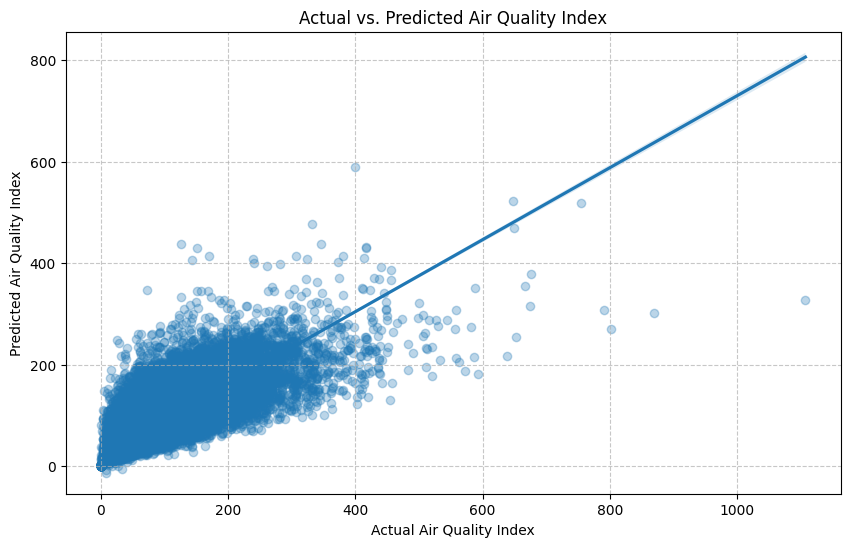

In [34]:
import matplotlib.pyplot as plt
fig = plt.figure(figsize=(10, 6))
sns.regplot(x=y_test, y=y_pred, scatter_kws={'alpha':0.3})
plt.xlabel("Actual Air Quality Index")
plt.ylabel("Predicted Air Quality Index")
plt.title("Actual vs. Predicted Air Quality Index")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [ ]:
# @title step_artifacts
num_fig = "1" # @param {type:"string"}
step = 'ModelEvaluation'  # @param ["DataLoading", "DataExploration", "DataCleaning", "DataWrangling", "DataVisualization", "DataSplitting", "ModelDevelopment", "ModelOptimization", "ModelEvaluation", "Summary"] {type:"string"}
# upload_plt_to_gcs(num_fig, step, fig)

### Feature Importance Visualization

Let's visualize the coefficients of our linear regression model to understand the relative importance and direction of influence of each feature on the predicted Air Quality Index.

/tmp/ipykernel_2489/100404295.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coefficient', y='Feature', data=feature_importance, palette='viridis')


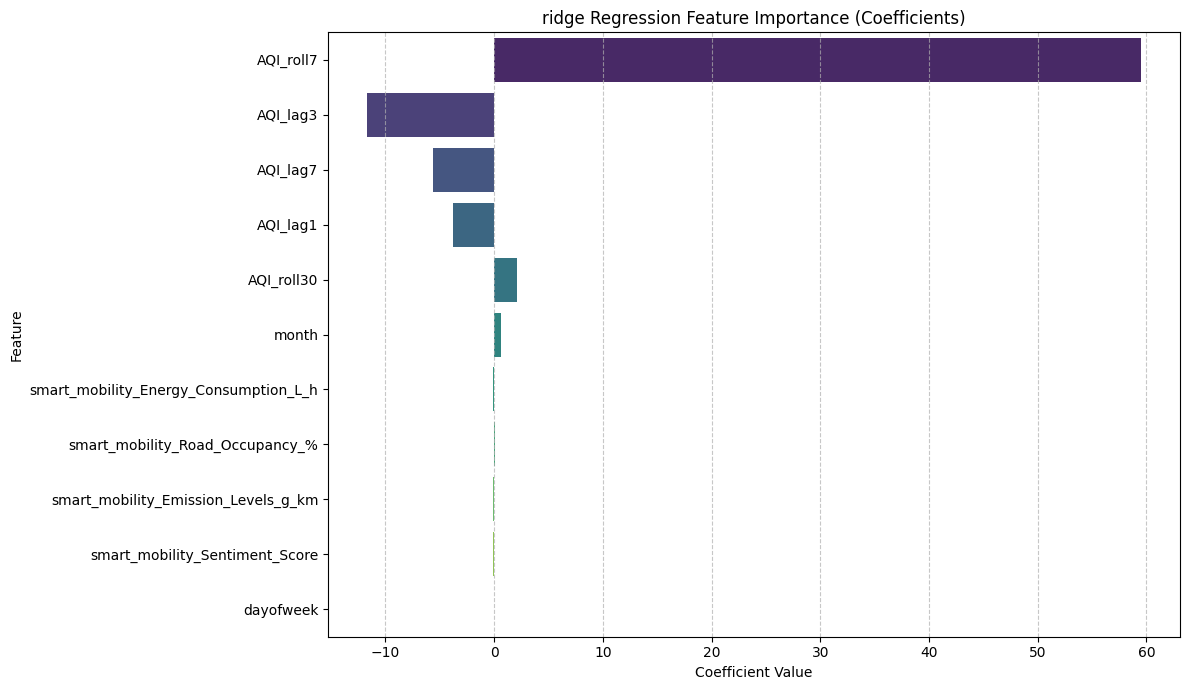

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Get feature names and their coefficients
feature_importance = pd.DataFrame({
    'Feature': features,
    'Coefficient': ridge_model.coef_
})

# Sort by absolute coefficient value for better visualization
feature_importance['Abs_Coefficient'] = feature_importance['Coefficient'].abs()
feature_importance = feature_importance.sort_values(by='Abs_Coefficient', ascending=False)

# Create the bar plot
fig = plt.figure(figsize=(12, 7))
sns.barplot(x='Coefficient', y='Feature', data=feature_importance, palette='viridis')
plt.title('ridge Regression Feature Importance (Coefficients)')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
# @title step_artifacts
num_fig = "2" # @param {type:"string"}
step = 'ModelEvaluation'  # @param ["DataLoading", "DataExploration", "DataCleaning", "DataWrangling", "DataVisualization", "DataSplitting", "ModelDevelopment", "ModelOptimization", "ModelEvaluation", "Summary"] {type:"string"}
# upload_plt_to_gcs(num_fig, step, fig)

As observed from the visualization, all the features have coefficients extremely close to zero, which reaffirms our earlier conclusion that these particular smart mobility features, in a linear relationship, do not significantly contribute to predicting the Air Quality Index in this model.

### Training a Non-Linear Model: Random Forest Regressor

Given the low R-squared and negligible coefficients from the linear regression model, it's highly likely that the relationship between our chosen features and the `Air_Quality_Index` is non-linear. Let's try a Random Forest Regressor, which is an ensemble learning method capable of capturing complex non-linear patterns and interactions between features.

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV # Changed from GridSearchCV

# Define model
rf = RandomForestRegressor(random_state=42, n_jobs=-1)

# Hyperparameter grid
param_grid = {
    'n_estimators': [100, 200, 500],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

# Randomized Search
# Set n_iter to control the number of parameter settings that are sampled
random_search = RandomizedSearchCV(estimator=rf, param_distributions=param_grid,
                                   n_iter=10, cv=2, scoring='neg_mean_squared_error', n_jobs=-1, random_state=42)

random_search.fit(X_train, y_train)

print("Best Parameters:", random_search.best_params_)
best_rf = random_search.best_estimator_

# Evaluate
rf_y_pred = best_rf.predict(X_test)
rf_mse = mean_squared_error(y_test, rf_y_pred)
rf_r2 = r2_score(y_test, rf_y_pred)

print(f"Random Forest MSE: {rf_mse:.2f}")
print(f"Random Forest R²: {rf_r2:.2f}")

### Visualization of Random Forest Predictions

Let's visualize the actual vs. predicted AQI values for the Random Forest model.

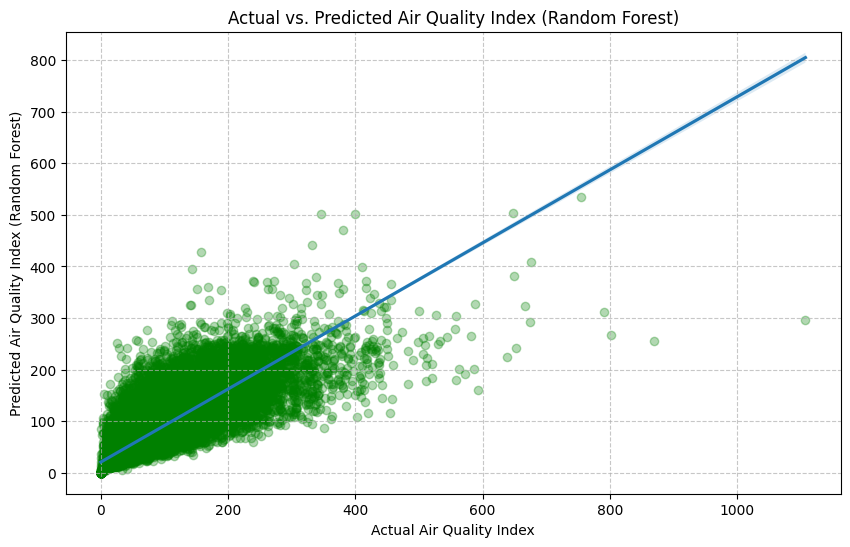

In [37]:
fig_rf_pred = plt.figure(figsize=(10, 6))
sns.regplot(x=y_test, y=rf_y_pred, scatter_kws={'alpha':0.3, 'color': 'green'})
plt.xlabel("Actual Air Quality Index")
plt.ylabel("Predicted Air Quality Index (Random Forest)")
plt.title("Actual vs. Predicted Air Quality Index (Random Forest)")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [ ]:
# @title step_artifacts
num_fig = "3" # @param {type:"string"}
step = 'ModelOptimization'  # @param ["DataLoading", "DataExploration", "DataCleaning", "DataWrangling", "DataVisualization", "DataSplitting", "ModelDevelopment", "ModelOptimization", "ModelEvaluation", "Summary"] {type:"string"}
# upload_plt_to_gcs(num_fig, step, fig_rf_pred)

### Random Forest Feature Importance

Random Forest models inherently provide a measure of feature importance. Let's visualize these to understand which smart mobility factors the model found most relevant for predicting AQI.

In [ ]:
rf_feature_importance = pd.DataFrame({
    'Feature': features,
    'Importance': rf_model.feature_importances_
})

rf_feature_importance = rf_feature_importance.sort_values(by='Importance', ascending=False)

fig_rf_imp = plt.figure(figsize=(12, 7))
sns.barplot(x='Importance', y='Feature', data=rf_feature_importance, palette='coolwarm')
plt.title('Random Forest Feature Importance for AQI Prediction')
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
# @title step_artifacts
num_fig = "4" # @param {type:"string"}
step = 'ModelOptimization'  # @param ["DataLoading", "DataExploration", "DataCleaning", "DataWrangling", "DataVisualization", "DataSplitting", "ModelDevelopment", "ModelOptimization", "ModelEvaluation", "Summary"] {type:"string"}
# upload_plt_to_gcs(num_fig, step, fig_rf_imp)

### Saving the Linear Regression Model

We can save the trained linear regression model using `joblib` so it can be reloaded and used later without retraining.

In [ ]:
import joblib

# Save both model and scaler
joblib.dump(model, "linear_model.joblib")
joblib.dump(scaler, "scaler.joblib")


print(f"Linear regression model saved successfully to {model_filename}")

In [ ]:
output_filename = 'merged_air_quality_mobility.csv'
merged_spatial_df.to_csv(output_filename, index=False)
print(f"Merged data saved successfully to {output_filename}")

Hyperparameter tuning

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

# Define model
rf = RandomForestRegressor(random_state=42)

# Hyperparameter grid
param_grid = {
    'n_estimators': [200, 500, 1000],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

# Grid search
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid,
                           cv=5, scoring='neg_mean_squared_error', n_jobs=-1)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
best_rf = grid_search.best_estimator_


### Incorporating 7-day Rolling Average AQI and KFold Cross-Validation

In [ ]:
import numpy as np
from sklearn.model_selection import KFold
import pandas as pd

# Convert 'date' column to datetime objects and sort for rolling average calculation
merged_spatial_df['date'] = pd.to_datetime(merged_spatial_df['date'])
merged_spatial_df_sorted = merged_spatial_df.sort_values(by=['location', 'date'])

# Calculate 7-day rolling average of 'Air_Quality_Index' for each location
# Using `transform` to broadcast the result back to the original DataFrame shape
merged_spatial_df_sorted['AQI_7Day_Rolling_Avg'] = merged_spatial_df_sorted.groupby('location')['Air_Quality_Index'].transform(lambda x: x.rolling(window=7, min_periods=1).mean())

# Define target and features using the new rolling average AQI
target_rolling_avg = 'AQI_7Day_Rolling_Avg'

# Drop rows where the new target or any of the selected features are NaN
regression_df_rolling_avg = merged_spatial_df_sorted[[target_rolling_avg] + features].dropna()

X_rolling_avg = regression_df_rolling_avg[features]
y_rolling_avg = regression_df_rolling_avg[target_rolling_avg]

print(f"Dataset size for rolling average model: {X_rolling_avg.shape[0]} rows")
display(regression_df_rolling_avg[[target_rolling_avg] + features].head())

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV, KFold # Changed from GridSearchCV

# Define model
rf_rolling = RandomForestRegressor(random_state=42)

# Hyperparameter grid (expanded for richer exploration)
param_grid_rich = {
    'n_estimators': [100, 200, 500],
    'max_depth': [5, 10, 20, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8],
    'max_features': ['sqrt', 'log2', 0.5, 0.8] # Added fractional max_features
}

# KFold Cross-Validation setup
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Randomized Search with KFold
# Increased n_iter for the richer parameter grid
random_search_rolling = RandomizedSearchCV(estimator=rf_rolling, param_distributions=param_grid_rich,
                                           n_iter=100, cv=kf, scoring='neg_mean_squared_error', n_jobs=-1, verbose=2, random_state=42)

random_search_rolling.fit(X_rolling_avg, y_rolling_avg)

print("\nBest Parameters for Rolling Average AQI Model:", random_search_rolling.best_params_)
best_rf_rolling = random_search_rolling.best_estimator_

### Evaluating the Optimized Random Forest Model

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

# It's important to evaluate the best model on a held-out test set if not doing full cross-validation metrics.
# However, since GridSearchCV already uses CV for evaluation, we'll re-split for a final test evaluation.
# For proper evaluation, a separate test set should have been defined before GridSearchCV.
# For demonstration, we'll use the *entire* X_rolling_avg, y_rolling_avg dataset for a final split here.

# Split the data into training and testing sets (80% train, 20% test) again for a fresh evaluation
# This ensures the test set was not part of the GridSearchCV training folds.
X_train_final, X_test_final, y_train_final, y_test_final = train_test_split(
    X_rolling_avg, y_rolling_avg, test_size=0.2, random_state=42)

# Make predictions on the final test set using the best estimator
best_rf_y_pred_final = best_rf_rolling.predict(X_test_final)

# Evaluate the best model
best_rf_mse_final = mean_squared_error(y_test_final, best_rf_y_pred_final)
best_rf_r2_final = r2_score(y_test_final, best_rf_y_pred_final)

print(f"\nOptimized Random Forest Mean Squared Error (MSE) on test set: {best_rf_mse_final:.2f}")
print(f"Optimized Random Forest R-squared (R2) on test set: {best_rf_r2_final:.2f}")

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize actual vs. predicted values for the optimized model
fig_best_rf_pred = plt.figure(figsize=(10, 6))
sns.regplot(x=y_test_final, y=best_rf_y_pred_final, scatter_kws={'alpha':0.3, 'color': 'purple'})
plt.xlabel("Actual 7-Day Rolling Average AQI")
plt.ylabel("Predicted 7-Day Rolling Average AQI (Optimized RF)")
plt.title("Actual vs. Predicted 7-Day Rolling Average AQI (Optimized Random Forest)")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [ ]:
import pandas as pd

# Get feature importance from the best estimator
best_rf_feature_importance = pd.DataFrame({
    'Feature': features,
    'Importance': best_rf_rolling.feature_importances_
})

best_rf_feature_importance = best_rf_feature_importance.sort_values(by='Importance', ascending=False)

fig_best_rf_imp = plt.figure(figsize=(12, 7))
sns.barplot(x='Importance', y='Feature', data=best_rf_feature_importance, palette='viridis')
plt.title('Optimized Random Forest Feature Importance for Rolling Average AQI Prediction')
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()